Total de exemplos: 15
Classes: {'nenhuma': 3, 'gelatinosa': 8, 'dura': 4}

  ENTROPIA(S)   |S| = 15
  Distribuicao: {'nenhuma': 3, 'gelatinosa': 8, 'dura': 4}

  nenhuma     : 3/15=0.2000  contrib=0.4644
  gelatinosa  : 8/15=0.5333  contrib=0.4837
  dura        : 4/15=0.2667  contrib=0.5085

  H(S) = (-3/15)log2(3/15) + (-8/15)log2(8/15) + (-4/15)log2(4/15)
       = 1.4566  arred: 1.46

  ATRIBUTO: IDADE
  H(S) = 1.46

    Idade="jovem": {'nenhuma': 1, 'gelatinosa': 2, 'dura': 1}  |S|=4
    H = -(1/4)log2(1/4) + -(2/4)log2(2/4) + -(1/4)log2(1/4) = 1.5000 ≈ 1.50
    peso = 4/15 = 0.2667

    Idade="pre-presbiopia": {'gelatinosa': 2, 'nenhuma': 1, 'dura': 2}  |S|=5
    H = -(2/5)log2(2/5) + -(1/5)log2(1/5) + -(2/5)log2(2/5) = 1.5219 ≈ 1.52
    peso = 5/15 = 0.3333

    Idade="presbiopia": {'gelatinosa': 4, 'dura': 1, 'nenhuma': 1}  |S|=6
    H = -(4/6)log2(4/6) + -(1/6)log2(1/6) + -(1/6)log2(1/6) = 1.2516 ≈ 1.25
    peso = 6/15 = 0.4000

  H(Idade) = 1.41
  IG(S, Idade) = 1.46 - 1.41 = 0

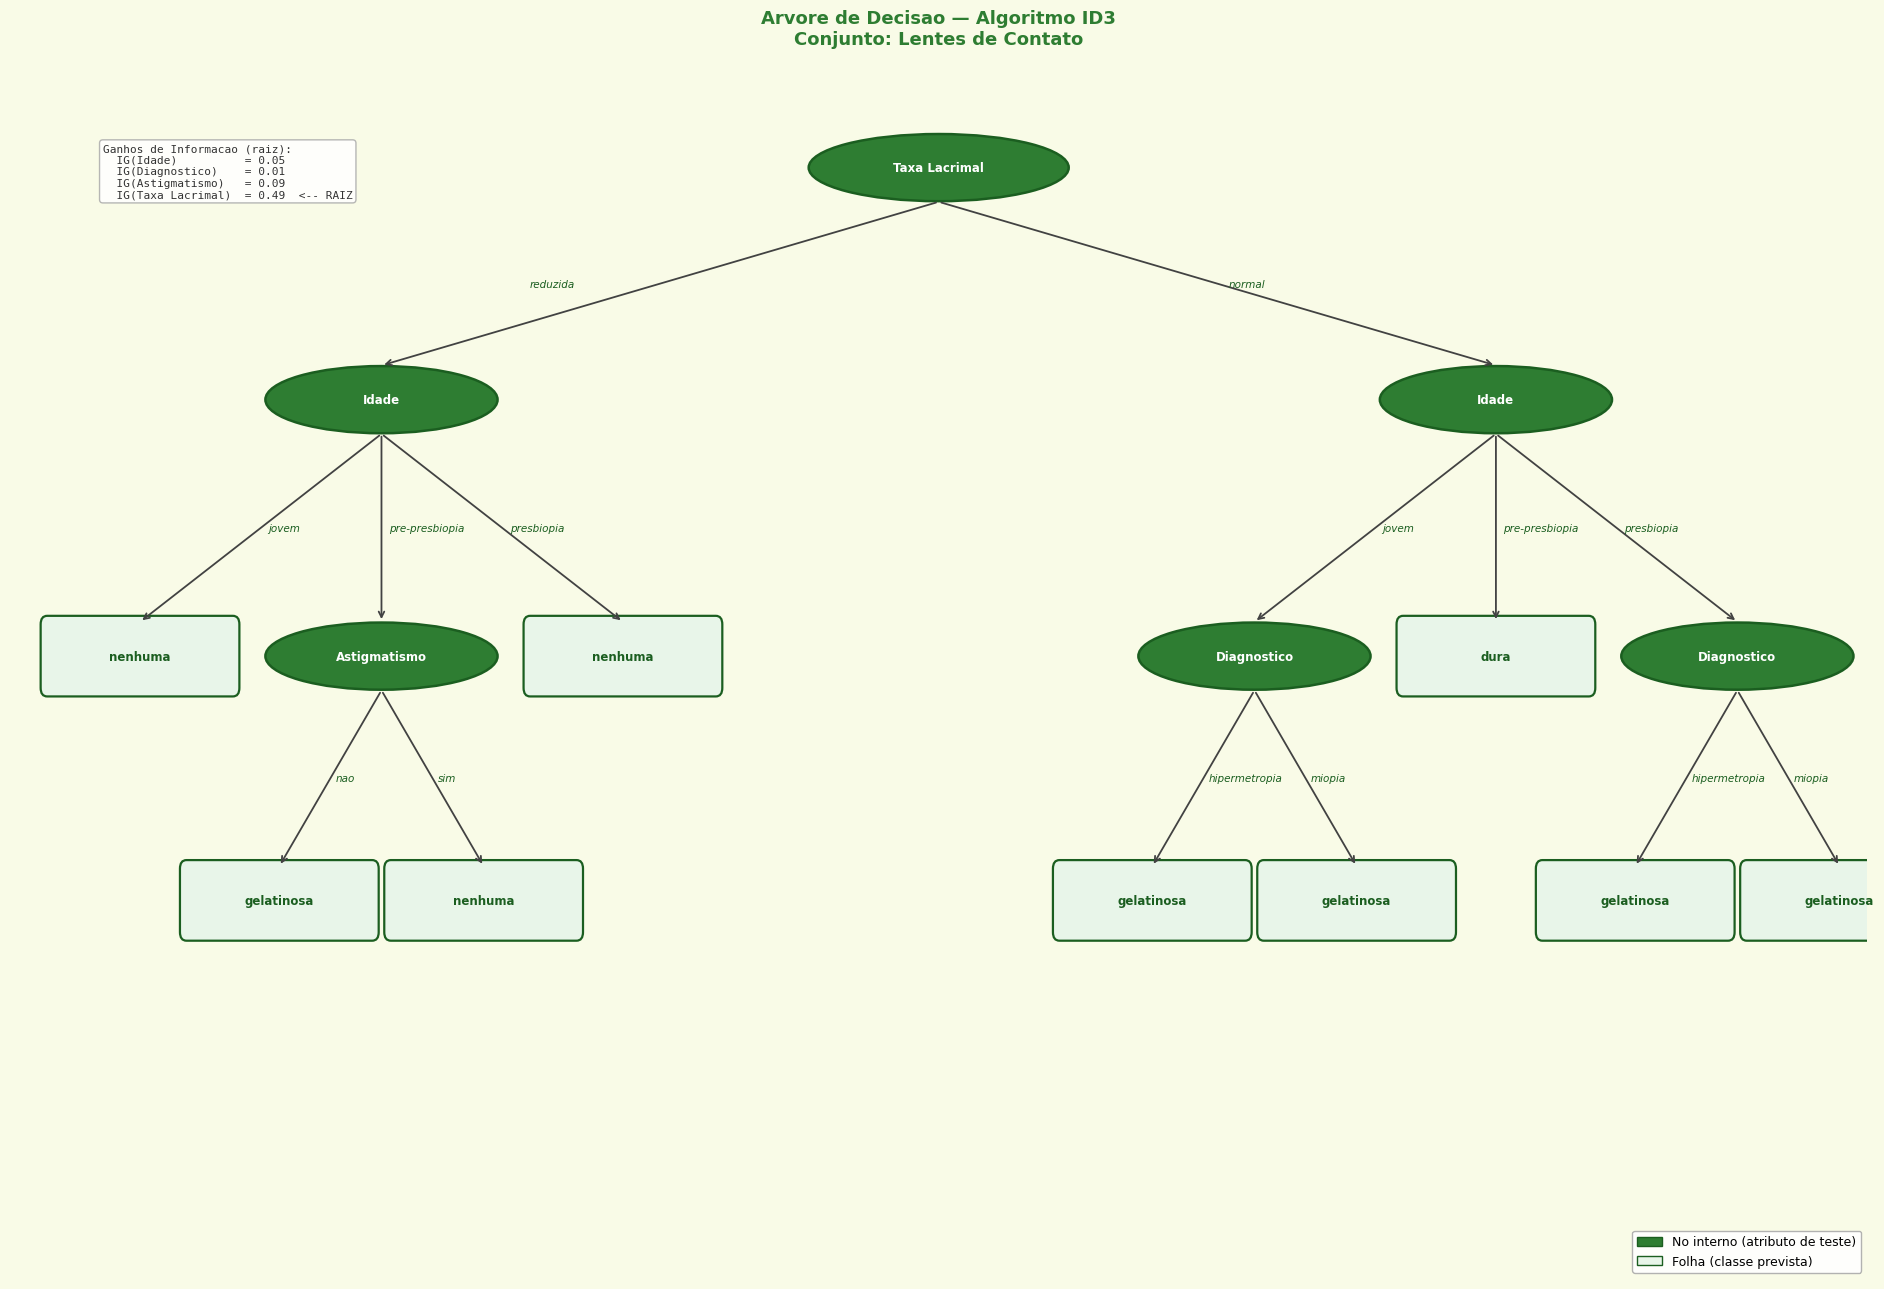

In [30]:
import math, warnings
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
from IPython.display import Image, display
warnings.filterwarnings('ignore')

# Índices: 0=Idade  1=Diagnóstico  2=Astigmatismo  3=Taxa Lacrimal  4=Classe
data = [
    ('jovem',         'miopia',        'nao', 'reduzida', 'nenhuma'),
    ('jovem',         'miopia',        'sim', 'normal',   'gelatinosa'),
    ('jovem',         'hipermetropia', 'nao', 'normal',   'gelatinosa'),
    ('jovem',         'hipermetropia', 'sim', 'normal',   'dura'),
    ('pre-presbiopia','miopia',        'nao', 'reduzida', 'gelatinosa'),
    ('pre-presbiopia','miopia',        'sim', 'reduzida', 'nenhuma'),
    ('pre-presbiopia','miopia',        'nao', 'normal',   'dura'),
    ('pre-presbiopia','hipermetropia', 'nao', 'reduzida', 'gelatinosa'),
    ('pre-presbiopia','hipermetropia', 'sim', 'normal',   'dura'),
    ('presbiopia',    'miopia',        'nao', 'normal',   'gelatinosa'),
    ('presbiopia',    'miopia',        'sim', 'normal',   'dura'),
    ('presbiopia',    'miopia',        'sim', 'normal',   'gelatinosa'),
    ('presbiopia',    'hipermetropia', 'nao', 'reduzida', 'nenhuma'),
    ('presbiopia',    'hipermetropia', 'sim', 'normal',   'gelatinosa'),
    ('presbiopia',    'hipermetropia', 'nao', 'normal',   'gelatinosa'),
]

ATTR = {0:'Idade', 1:'Diagnostico', 2:'Astigmatismo', 3:'Taxa Lacrimal'}
print(f'Total de exemplos: {len(data)}')
print('Classes:', dict(Counter(r[4] for r in data)))

def H(subset):
    n = len(subset)
    if n == 0: return 0.0
    return sum(-k/n * math.log2(k/n) for k in Counter(r[4] for r in subset).values())

def IG(subset, idx):
    n  = len(subset)
    hs = H(subset)
    ha = sum(len(sv)/n * H(sv)
             for v in set(r[idx] for r in subset)
             for sv in [[r for r in subset if r[idx]==v]])
    return round(hs,4), round(ha,4), round(hs-ha,4)

def detalhe(subset, idx):
    n = len(subset)
    for v in sorted(set(r[idx] for r in subset)):
        sv = [r for r in subset if r[idx]==v]
        hv = H(sv)
        dist = dict(Counter(r[4] for r in sv))
        print(f'    {ATTR[idx]}="{v}": {dist}  |S|={len(sv)}')
        partes = [f'-({k}/{len(sv)})log2({k}/{len(sv)})' for k in dist.values()]
        print(f'    H = {" + ".join(partes)} = {hv:.4f} ≈ {hv:.2f}')
        print(f'    peso = {len(sv)}/{n} = {len(sv)/n:.4f}')
        print()

n_tot = len(data)
cnt   = Counter(r[4] for r in data)
H_S   = H(data)

print('\n==========================================================')
print(f'  ENTROPIA(S)   |S| = {n_tot}')
print('==========================================================')
print(f'  Distribuicao: {dict(cnt)}')
print()
termos = []
for cls, k in cnt.items():
    p = k/n_tot
    c = -p*math.log2(p)
    termos.append(f'(-{k}/{n_tot})log2({k}/{n_tot})')
    print(f'  {cls:12s}: {k}/{n_tot}={p:.4f}  contrib={c:.4f}')
print()
print(f'  H(S) = {" + ".join(termos)}')
print(f'       = {H_S:.4f}  arred: {H_S:.2f}')

ganhos_raiz = {}

for idx in [0,1,2,3]:
    hs, ha, ig = IG(data, idx)
    ganhos_raiz[idx] = ig
    print('\n============================================================')
    print(f'  ATRIBUTO: {ATTR[idx].upper()}')
    print('============================================================')
    print(f'  H(S) = {hs:.2f}')
    print()
    detalhe(data, idx)
    print(f'  H({ATTR[idx]}) = {ha:.2f}')
    print(f'  IG(S, {ATTR[idx]}) = {hs:.2f} - {ha:.2f} = {ig:.2f}')
    print()

print('='*58)
print('  RESUMO — GANHOS DE INFORMACAO (raiz)')
print('='*58)
melhor_raiz = max(ganhos_raiz, key=ganhos_raiz.get)
for idx, ig in ganhos_raiz.items():
    seta = '  <-- RAIZ' if idx == melhor_raiz else ''
    print(f'  IG(S, {ATTR[idx]:16s}) = {ig:.2f}{seta}')
print('='*58)
print(f'\n  Atributo RAIZ: {ATTR[melhor_raiz]}  (IG = {ganhos_raiz[melhor_raiz]:.2f})')

S_red = [r for r in data if r[3]=='reduzida']
H_red = H(S_red)
cnt_red = Counter(r[4] for r in S_red)

print('\n==========================================================')
print('  SUBCONJUNTO  S_reduzida  (Taxa Lacrimal = reduzida)')
print('==========================================================')
for i,r in enumerate(S_red):
    print(f'  [{i}] Idade={r[0]}, Diag={r[1]}, Asti={r[2]}  Classe={r[4]}')
print()
print(f'  |S_reduzida| = {len(S_red)}')
print(f'  Distribuicao: {dict(cnt_red)}')
print()
print(f'  H(S_reduzida) = {H_red:.4f}  arred: {H_red:.2f}')
if H_red == 0:
    print()
    print('  H = 0  --> SUBCONJUNTO PURO --> NO FOLHA!')
    print(f'  Classe: {S_red[0][4]}')
else:
    print(f'  H > 0  --> impuro, calcular ganhos dos sub-atributos')

if H_red > 0:
    ganhos_red = {}
    print('\n============================================================')
    print('  GANHOS DE INFORMACAO — Ramo reduzida')
    print('============================================================')
    for idx in [0,1,2]:
        hs, ha, ig = IG(S_red, idx)
        ganhos_red[idx] = ig
        print(f'\n  -- Atributo: {ATTR[idx]} --')
        print(f'  H(S_red) = {hs:.2f}')
        print()
        detalhe(S_red, idx)
        print(f'  H({ATTR[idx]}) = {ha:.2f}')
        print(f'  IG(S_red, {ATTR[idx]}) = {hs:.2f} - {ha:.2f} = {ig:.2f}')
    print()
    print('='*58)
    print('  RESUMO — Ramo reduzida')
    print('='*58)
    melhor_red = max(ganhos_red, key=ganhos_red.get)
    for idx, ig in ganhos_red.items():
        seta = '  <-- ESCOLHIDO' if idx == melhor_red else ''
        print(f'  IG(S_red, {ATTR[idx]:16s}) = {ig:.2f}{seta}')
    print('='*58)
    print(f'\n  Atributo escolhido: {ATTR[melhor_red]}')
else:
    print('Subconjunto puro. Nenhum calculo adicional necessario.')


# ─── Utilitarios de desenho ───────────────────────────────────────────────
CN = '#2e7d32'  # verde escuro
CF = '#e8f5e9'  # verde claro
CB = '#1b5e20'  # borda
CS = '#424242'  # seta

def no(ax, x, y, txt, w=2.5, h=0.55):
    ax.add_patch(mpatches.Ellipse((x,y), w, h, lw=1.8, ec=CB, fc=CN))
    ax.text(x, y, txt, ha='center', va='center',
            fontsize=8.5, fontweight='bold', color='white')

def folha(ax, x, y, txt, w=2.0, h=0.52):
    ax.add_patch(FancyBboxPatch((x-w/2,y-h/2), w, h,
                                boxstyle='round,pad=0.07',
                                lw=1.6, ec=CB, fc=CF))
    ax.text(x, y, txt, ha='center', va='center',
            fontsize=8.5, fontweight='bold', color='#1b5e20')

def seta(ax, x1, y1, x2, y2, lbl, dx=0.1):
    ax.annotate('', xy=(x2,y2+0.28), xytext=(x1,y1-0.28),
                arrowprops=dict(arrowstyle='->', color=CS, lw=1.3))
    ax.text((x1+x2)/2+dx, (y1+y2)/2, lbl,
            ha='left', va='center', fontsize=7.5,
            color=CB, style='italic')

def classe_majoritaria(subset):
    return Counter(r[4] for r in subset).most_common(1)[0][0] if subset else '?'

def puro(subset):
    return len(set(r[4] for r in subset)) <= 1

fig, ax = plt.subplots(figsize=(19, 13))
ax.set_xlim(-0.5, 19.5)
ax.set_ylim(-0.8, 9.2)
ax.axis('off')
fig.patch.set_facecolor('#f9fbe7')
ax.set_facecolor('#f9fbe7')
ax.set_title('Arvore de Decisao — Algoritmo ID3\nConjunto: Lentes de Contato',
             fontsize=13, fontweight='bold', color=CN, pad=10)

# ─── Nivel 0: Raiz ──────────────────────────────────────────────────────
rx, ry = 9.5, 8.3
no(ax, rx, ry, 'Taxa Lacrimal', w=2.8)

# ─── Nivel 1 ────────────────────────────────────────────────────────────
ramos_taxa = {'reduzida': 3.5, 'normal': 15.5}
y1 = 6.4

for taxa, xf in ramos_taxa.items():
    dx = -1.4 if taxa == 'reduzida' else 0.12
    seta(ax, rx, ry, xf, y1, taxa, dx=dx)
    sub1 = [r for r in data if r[3] == taxa]

    if puro(sub1):
        folha(ax, xf, y1, classe_majoritaria(sub1))
        continue

    # Melhor atributo neste nivel
    best1 = max([0,1,2], key=lambda i: IG(sub1,i)[2])
    no(ax, xf, y1, ATTR[best1], w=2.5)

    # Nivel 2
    vals1 = sorted(set(r[best1] for r in sub1))
    n1    = len(vals1)
    # Posicoes x dos filhos
    if taxa == 'reduzida':
        xs2 = [xf - 2.6, xf + 0.0, xf + 2.6] if n1 == 3 else [xf - 1.5, xf + 1.5]
    else:
        xs2 = [xf - 2.6, xf + 0.0, xf + 2.6] if n1 == 3 else [xf - 1.5, xf + 1.5]

    y2 = 4.3
    for i, v1 in enumerate(vals1):
        sub2 = [r for r in sub1 if r[best1] == v1]
        x2   = xs2[i]
        seta(ax, xf, y1, x2, y2, str(v1), dx=0.08)

        if puro(sub2):
            folha(ax, x2, y2, classe_majoritaria(sub2))
            continue

        # Nivel 3
        rem   = [j for j in [0,1,2] if j != best1]
        best2 = max(rem, key=lambda i: IG(sub2,i)[2])
        no(ax, x2, y2, ATTR[best2], w=2.5)

        vals2 = sorted(set(r[best2] for r in sub2))
        y3    = 2.3
        if len(vals2) == 2:
            xs3 = [x2 - 1.1, x2 + 1.1]
        elif len(vals2) == 3:
            xs3 = [x2 - 2.0, x2, x2 + 2.0]
        else:
            xs3 = [x2]

        for j, v2 in enumerate(vals2):
            sub3 = [r for r in sub2 if r[best2] == v2]
            x3   = xs3[j]
            seta(ax, x2, y2, x3, y3, str(v2), dx=0.06)
            folha(ax, x3, y3, classe_majoritaria(sub3))

# ─── Legenda ────────────────────────────────────────────────────────────
leg = [
    mpatches.Patch(fc=CN, ec=CB, label='No interno (atributo de teste)'),
    mpatches.Patch(fc=CF, ec=CB, label='Folha (classe prevista)'),
]
ax.legend(handles=leg, loc='lower right', fontsize=9,
          framealpha=0.9, edgecolor='#aaa')

# ─── Anotacao dos ganhos na raiz ────────────────────────────────────────
txt  = (
    f'Ganhos de Informacao (raiz):\n'
    f'  IG(Idade)          = {ganhos_raiz[0]:.2f}\n'
    f'  IG(Diagnostico)    = {ganhos_raiz[1]:.2f}\n'
    f'  IG(Astigmatismo)   = {ganhos_raiz[2]:.2f}\n'
    f'  IG(Taxa Lacrimal)  = {ganhos_raiz[3]:.2f}  <-- RAIZ'
)
ax.text(0.5, 8.5, txt, fontsize=8, va='top',
        family='monospace', color='#333',
        bbox=dict(boxstyle='round', fc='white', ec='#aaa', alpha=0.85))

plt.tight_layout()
plt.savefig('arvore_lentes_contato.png', dpi=150, bbox_inches='tight')
plt.show()
